In [101]:
import sklearn
import numpy as np
from sklearn.base import BaseEstimator



In [102]:
class MyDummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]):
            if X["Sex"].iloc[i] == 1:
                pred[i] = 0
            else:
                pred[i] = 1

        return pred

In [103]:
from sklearn.preprocessing import LabelEncoder

def fillna(df):
    df["Age"] = df["Age"].fillna(df["Age"].mean())
    df["Cabin"] = df["Cabin"].fillna("N")
    df["Embarked"] = df["Embarked"].fillna("N")
    df["Fare"] = df["Fare"].fillna(0)

    return df

def drop_features(df):
    df.drop(["PassengerId", "Name", "Ticket"], axis = 1, inplace=True)
    return df

In [104]:
def format_features(df):
    df["Cabin"] = df["Cabin"].str[:1]
    features = ["Cabin", "Sex", "Embarked"]
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])

    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df


In [105]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

titanic_df = pd.read_csv("./data/train.csv")

y_titanic_df = titanic_df["Survived"]
X_titanic_df = titanic_df.drop("Survived", axis = 1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state = 42)

myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)

mypred = myclf.predict(X_test)

print(accuracy_score(y_test, mypred))

0.7821229050279329


In [106]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self, X, y):
        pass

    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

digits = load_digits()

print(digits.data)
print(digits.data.shape)
print(digits.target)
print(digits.target.shape)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
(1797, 64)
[0 1 2 ... 8 9 8]
(1797,)


In [107]:
digits.target == 7

array([False, False, False, ..., False, False, False], shape=(1797,))

In [108]:
y = (digits.target == 7).astype(int)

X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=42)


In [109]:
print(y_test.shape)
print(pd.Series(y_test).value_counts())

(450,)
0    409
1     41
Name: count, dtype: int64


In [110]:
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)

print(accuracy_score(y_test, fakepred))

0.9088888888888889


In [111]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, fakepred)

array([[409,   0],
       [ 41,   0]])

In [112]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print(precision_score(y_test, fakepred))
print(recall_score(y_test, fakepred))


0.0
0.0


c:\Users\KDS-22\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [113]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    print(confusion)
    print(accuracy, precision, recall)

In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

titanic_df = pd.read_csv("./data/train.csv")
y_titanic_df = titanic_df["Survived"]
X_titanic_df = titanic_df.drop("Survived", axis = 1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=42)

lr_clf = LogisticRegression(solver="liblinear")

lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)

get_clf_eval(y_test, pred)

[[90 15]
 [22 52]]
0.7932960893854749 0.7761194029850746 0.7027027027027027


In [115]:
pred_prob = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

print(pred_prob.shape)
print(pred_prob[:3])

pred_prob_result = np.concatenate([pred_prob, pred.reshape(-1, 1)], axis = 1)
print(pred_prob_result[:3])

(179, 2)
[[0.88326729 0.11673271]
 [0.79435927 0.20564073]
 [0.85185926 0.14814074]]
[[0.88326729 0.11673271 0.        ]
 [0.79435927 0.20564073 0.        ]
 [0.85185926 0.14814074 0.        ]]


In [116]:
from sklearn.preprocessing import Binarizer

custom_threshold = 0.5

pred_prob_1 = pred_prob[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_1)
custom_predict = binarizer.transform(pred_prob_1)

get_clf_eval(y_test, custom_predict)

[[90 15]
 [22 52]]
0.7932960893854749 0.7761194029850746 0.7027027027027027


In [117]:
custom_threshold = 0.4

pred_prob_1 = pred_prob[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_1)
custom_predict = binarizer.transform(pred_prob_1)

get_clf_eval(y_test, custom_predict)

[[85 20]
 [17 57]]
0.7932960893854749 0.7402597402597403 0.7702702702702703


In [118]:
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test, pred_prob_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_c1)
        custom_predict = binarizer.transform(pred_prob_c1)
        print("임계값 :", custom_threshold)
        get_clf_eval(y_test, custom_predict)

get_eval_by_threshold(y_test, pred_prob[:, 1].reshape(-1, 1), thresholds)

임계값 : 0.4
[[85 20]
 [17 57]]
0.7932960893854749 0.7402597402597403 0.7702702702702703
임계값 : 0.45
[[89 16]
 [20 54]]
0.7988826815642458 0.7714285714285715 0.7297297297297297
임계값 : 0.5
[[90 15]
 [22 52]]
0.7932960893854749 0.7761194029850746 0.7027027027027027
임계값 : 0.55
[[91 14]
 [23 51]]
0.7932960893854749 0.7846153846153846 0.6891891891891891
임계값 : 0.6
[[94 11]
 [24 50]]
0.8044692737430168 0.819672131147541 0.6756756756756757


In [119]:
from sklearn.metrics import precision_recall_curve

pred_prob_class1 = lr_clf.predict_proba(X_test)[:, 1] 

precisions, recalls, thresholds = precision_recall_curve(y_test, pred_prob_class1 )
print(thresholds.shape)
print(precisions.shape)
print(recalls.shape)

print(thresholds[:5])
print(precisions[:5])
print(recalls[:5])

thr_index = np.arange(0, thresholds.shape[0], 15)
print(thr_index)
print(np.round(thresholds[thr_index], 2))

print(np.round(precisions[thr_index], 3))
print(np.round(recalls[thr_index], 3))

(174,)
(175,)
(175,)
[0.05884371 0.06136895 0.06951008 0.07668169 0.08599665]
[0.41340782 0.41573034 0.4180791  0.42045455 0.42285714]
[1. 1. 1. 1. 1.]
[  0  15  30  45  60  75  90 105 120 135 150 165]
[0.06 0.11 0.13 0.15 0.16 0.25 0.35 0.49 0.64 0.7  0.82 0.91]
[0.413 0.445 0.479 0.538 0.591 0.66  0.718 0.771 0.891 0.923 1.    1.   ]
[1.    0.986 0.946 0.946 0.919 0.892 0.824 0.73  0.662 0.486 0.324 0.122]


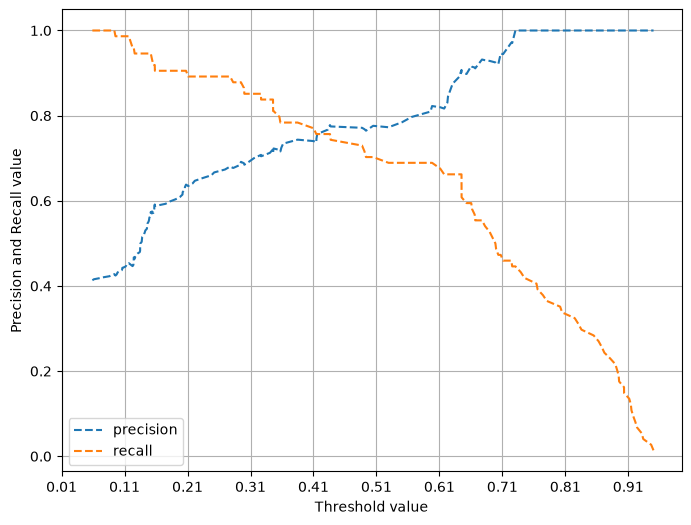

In [120]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test , pred_proba_c1):
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)
    
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],linestyle='--', label='recall')

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))

    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()
    
precision_recall_curve_plot( y_test, lr_clf.predict_proba(X_test)[:, 1] )

In [121]:
from sklearn.metrics import f1_score 
f1 = f1_score(y_test , pred)
print(f1)

0.7375886524822695


In [123]:
def get_clf_eval(y_test , pred):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)

    f1 = f1_score(y_test,pred)
    print(confusion)
    print(accuracy, precision, recall, f1)

thresholds = [0.4 , 0.45 , 0.50 , 0.55 , 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1,1), thresholds)

임계값 : 0.4
[[85 20]
 [17 57]]
0.7932960893854749 0.7402597402597403 0.7702702702702703 0.7549668874172185
임계값 : 0.45
[[89 16]
 [20 54]]
0.7988826815642458 0.7714285714285715 0.7297297297297297 0.75
임계값 : 0.5
[[90 15]
 [22 52]]
0.7932960893854749 0.7761194029850746 0.7027027027027027 0.7375886524822695
임계값 : 0.55
[[91 14]
 [23 51]]
0.7932960893854749 0.7846153846153846 0.6891891891891891 0.7338129496402878
임계값 : 0.6
[[94 11]
 [24 50]]
0.8044692737430168 0.819672131147541 0.6756756756756757 0.7407407407407407


In [124]:
from sklearn.metrics import roc_curve

pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1] 

fprs , tprs , thresholds = roc_curve(y_test, pred_proba_class1)

thr_index = np.arange(1, thresholds.shape[0], 5)
print(thr_index)
print(np.round(thresholds[thr_index], 2))

print(np.round(fprs[thr_index], 3))
print(np.round(tprs[thr_index], 3))

[ 1  6 11 16 21 26 31 36 41 46]
[0.95 0.71 0.65 0.53 0.38 0.33 0.28 0.16 0.13 0.12]
[0.    0.019 0.048 0.143 0.19  0.248 0.295 0.486 0.695 0.838]
[0.014 0.473 0.595 0.689 0.784 0.838 0.892 0.919 0.946 0.986]


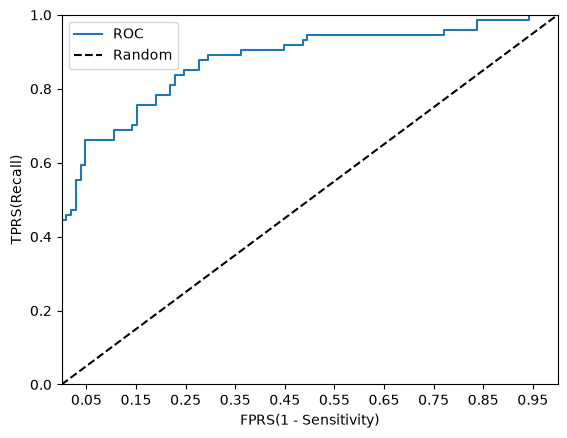

In [128]:
def roc_curve_plot(y_test , pred_proba_c1):

    fprs , tprs , thresholds = roc_curve(y_test ,pred_proba_c1)

    plt.plot(fprs , tprs, label='ROC')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
     
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPRS(1 - Sensitivity)')
    plt.ylabel('TPRS(Recall)')
    plt.legend()
    plt.show()
    
roc_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1] )

In [134]:
from sklearn.metrics import roc_auc_score
pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_auc_score1 = roc_auc_score(y_test, pred_proba)
print(roc_auc_score1)

0.8774774774774776


In [130]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
          F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))